# Performance Analytics
This notebook computes Sharpe Ratio, Beta, VaR, and CAGR for mutual funds.

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Constants
TRADING_DAYS = 252
RISK_FREE_RATE = 0.07 # 7% risk-free rate assumption

# Load processed data
nav_history = pd.read_csv('../data/processed/nav_history.csv')
nav_history['date'] = pd.to_datetime(nav_history['date'])

benchmark = pd.read_csv('../data/processed/benchmark_indices.csv')
benchmark['date'] = pd.to_datetime(benchmark['date'])
nifty50 = benchmark[benchmark['index_name'] == 'NIFTY50'].copy()
nifty50.sort_values('date', inplace=True)
nifty50.set_index('date', inplace=True)
nifty50['daily_return'] = nifty50['close_value'].pct_change()


## Calculate Daily Returns & CAGR

In [2]:
# Calculate daily returns for each fund
nav_history.sort_values(by=['amfi_code', 'date'], inplace=True)
nav_history['daily_return'] = nav_history.groupby('amfi_code')['nav'].pct_change()

# Calculate CAGR correctly using 252 trading days
def calculate_cagr(group):
    group = group.dropna(subset=['nav'])
    if len(group) < 2:
        return np.nan
    beginning_value = group['nav'].iloc[0]
    ending_value = group['nav'].iloc[-1]
    n_trading_days = len(group)
    if beginning_value <= 0 or n_trading_days == 0:
        return np.nan
    
    # annualized factor
    years = n_trading_days / TRADING_DAYS
    cagr = (ending_value / beginning_value) ** (1 / years) - 1
    return cagr

cagr_results = nav_history.groupby('amfi_code').apply(calculate_cagr).reset_index(name='CAGR')


C:\Users\FINTECH002\AppData\Local\Temp\ipykernel_37988\2540984738.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cagr_results = nav_history.groupby('amfi_code').apply(calculate_cagr).reset_index(name='CAGR')


## Volatility, Sharpe Ratio, Beta, and VaR

In [3]:
metrics = []
for amfi_code, group in nav_history.groupby('amfi_code'):
    group = group.dropna(subset=['daily_return'])
    if len(group) < 2:
        continue
    
    # Merge with NIFTY50 to compute Beta
    merged = pd.merge(group[['date', 'daily_return']], nifty50[['daily_return']], on='date', suffixes=('_fund', '_bench')).dropna()
    
    # 1. Volatility (Annualized)
    daily_vol = group['daily_return'].std()
    annual_vol = daily_vol * np.sqrt(TRADING_DAYS)
    
    # 2. Sharpe Ratio
    cagr = cagr_results.loc[cagr_results['amfi_code'] == amfi_code, 'CAGR'].values[0]
    sharpe_ratio = (cagr - RISK_FREE_RATE) / annual_vol if annual_vol > 0 else np.nan
    
    # 3. Beta
    if len(merged) > 1 and merged['daily_return_bench'].var() > 0:
        cov = np.cov(merged['daily_return_fund'], merged['daily_return_bench'])[0, 1]
        var_bench = merged['daily_return_bench'].var()
        beta = cov / var_bench
    else:
        beta = np.nan
        
    # 4. VaR (Historical 95%)
    var_95 = np.percentile(group['daily_return'], 5)
    
    metrics.append({
        'amfi_code': amfi_code,
        'CAGR': cagr,
        'Annualized_Volatility': annual_vol,
        'Sharpe_Ratio': sharpe_ratio,
        'Beta': beta,
        'Historical_VaR_95': var_95
    })

metrics_df = pd.DataFrame(metrics)

# Combine with fund master to get names
fund_master = pd.read_csv('../data/processed/fund_master.csv')
final_metrics = pd.merge(fund_master[['amfi_code', 'scheme_name', 'category', 'sub_category']], metrics_df, on='amfi_code', how='inner')

display(final_metrics.head())
final_metrics.to_csv('../data/processed/calculated_performance_metrics.csv', index=False)


,amfi_code,scheme_name,category,sub_category,CAGR,Annualized_Volatility,Sharpe_Ratio,Beta,Historical_VaR_95
0,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,0.171499,0.116365,0.872243,-0.056045,-0.011827
1,119552,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,0.143868,0.117988,0.626065,-0.019853,-0.012129
2,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,0.213657,0.212730,0.675303,0.074266,-0.021502
3,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,0.014121,0.210951,-0.264891,0.007681,-0.023155
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,0.040246,0.033578,-0.886111,0.011991,-0.003429


## Visualizing Risk vs Return

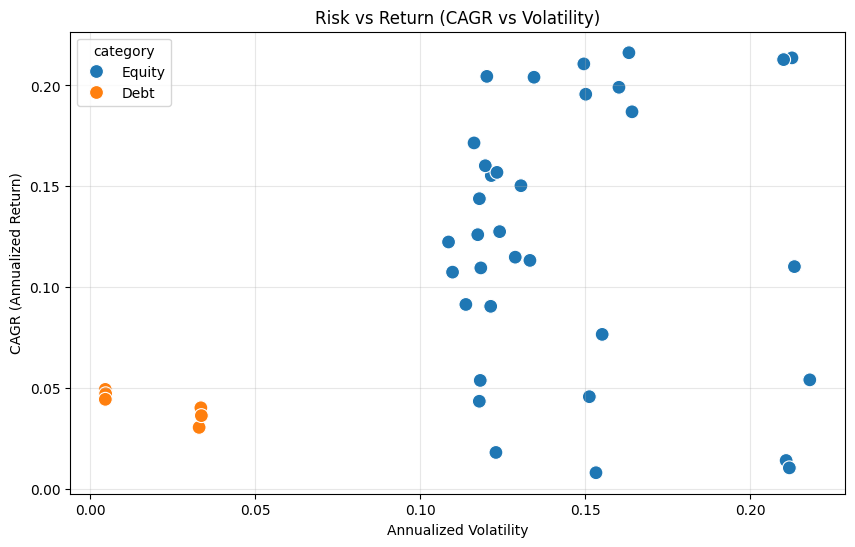

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_metrics, x='Annualized_Volatility', y='CAGR', hue='category', s=100)
plt.title('Risk vs Return (CAGR vs Volatility)')
plt.xlabel('Annualized Volatility')
plt.ylabel('CAGR (Annualized Return)')
plt.grid(True, alpha=0.3)
plt.show()
